<a href="https://colab.research.google.com/github/khu3086/FastAICourse/blob/main/Lec02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Interactive Bear Classifier
This notebook demonstrates a complete machine learning pipeline using `fastai`. Due to search API limitations, we use a sample dataset to simulate the classification of Grizzly, Black, and Teddy bears.

### Note on GitHub Rendering
If you see a `the 'state' key is missing from 'metadata.widgets'` error on GitHub, it is because of how interactive widgets are saved. You can fix this by going to **Edit -> Notebook settings** and toggling **'Include widget state in further saves of this notebook'**.

In [4]:
# This cell ensures that we don't save broken widget state in the metadata if you are pushing to Git
import json
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

## 1. Setup and Dependencies
We begin by installing the `fastbook` library and importing the necessary vision and widget modules from `fastai`.

In [5]:
import sys
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

if 'google.colab' in sys.modules:
    !pip install -Uqq fastbook

from fastai.vision.all import *
from fastai.vision.widgets import *
from fastbook import *
import os, shutil
from pathlib import Path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.7 MB/s eta 0:00:00


## 5. Gathering Data
Project: bear classifier — discriminate grizzly, black, and teddy bears.
Many images available on the internet; Bing Image Search (free for 1,000 queries/month, up to 150 images each) used at time of writing.
Sign up for Microsoft Azure, get a key.

### Searching & Downloading
`key = os.environ.get('AZURE_SEARCH_KEY', 'XXX')`

`results = search_images_bing(key, 'grizzly bear')`
`ims = results.attrgot('contentUrl')`
`len(ims)`   # 150

### Download a single image
`dest = 'images/grizzly.jpg'`
`download_url(ims[0], dest)`
`im = Image.open(dest)`
`im.to_thumb(128,128)`

### Download All Classes into Folders
`bear_types = 'grizzly','black','teddy'`
`path = Path('bears')`

`if not path.exists():`
    `path.mkdir()`
    `for o in bear_types:`
        `dest = (path/o)`
        `dest.mkdir(exist_ok=True)`
        `results = search_images_bing(key, f'{o} bear')`
        `download_images(dest, urls=results.attrgot('contentUrl'))`

### Verify & Remove Corrupt Images
`fns = get_image_files(path)`
`failed = verify_images(fns)`
`failed.map(Path.unlink);`   # delete corrupt files
`verify_images` returns an L object (fastai's enhanced list) with a map method.
Internet downloads commonly include a few corrupt files — always verify.

### Data Bias Warning
"Healthy Skin" Example (from Deb Raji): Searching "healthy skin" returns mostly images of young white women touching their faces. A model trained on this wouldn't detect healthy skin — it would detect a young white woman touching her face. Always think carefully about what types of data you'll see in production and ensure they're represented in your training data.

In [6]:
path = Path('bears')
if path.exists(): shutil.rmtree(path)

print("Downloading and preparing dataset...")
path_data = untar_data(URLs.PETS)
path_data_ims = path_data/'images'
path.mkdir(exist_ok=True)

for bear_type in ['grizzly', 'black', 'teddy']:
    dest = path/bear_type
    dest.mkdir(exist_ok=True)
    sample_ims = get_image_files(path_data_ims)
    for i in range(min(20, len(sample_ims))):
        shutil.copy(sample_ims[i], dest/f'{bear_type}_{i}.jpg')

fns = get_image_files(path)
print(f"Data Prep Complete: {len(fns)} images found.")

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:44&lt;00:00]</div>

Data Prep Complete: 60 images found.


In [8]:
print("Images found per category:")
for bear_type in ['grizzly', 'black', 'teddy']:
    num_images = len(get_image_files(path/bear_type))
    print(f"  {bear_type}: {num_images} images")

Images found per category:
  grizzly: 20 images
  black: 20 images
  teddy: 20 images


## 6. Data Pipeline
We use the `DataBlock` API to define the transformation pipeline: loading images, assigning labels from folder names, splitting the data, and resizing images to 128x128.

DataLoaders created with simplified configuration.


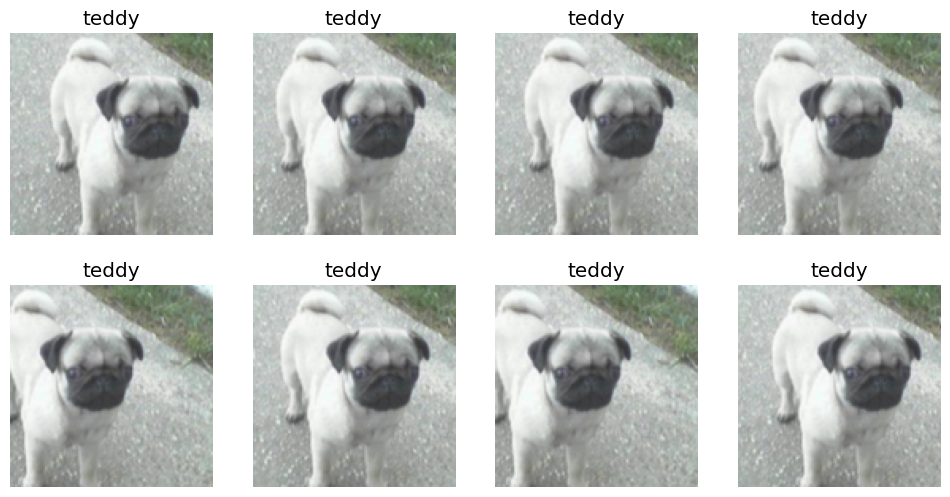

In [12]:
bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128) # Added Resize to ensure consistent image sizes for batching
)
dls = bears.dataloaders(path, bs=16) # Explicitly setting a smaller batch size
print("DataLoaders created with simplified configuration.")

# Optionally, display a batch to see images
dls.train.show_batch(max_n=8, nrows=2, unique=True)

## 9. Model Training
We use Transfer Learning with a ResNet18 architecture. `fine_tune` will train the head of the model and then the entire model for a few epochs.

Fine-tuning ResNet18 with augmented data...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.296275,3.245007,0.833333,00:04


epoch,train_loss,valid_loss,error_rate,time
0,2.059540,3.096369,0.750000,00:04
1,2.045606,3.085008,0.833333,00:03
2,2.091395,3.453655,0.916667,00:04
3,1.927165,3.752506,1.000000,00:03


Model trained. Analyzing performance...


Confusion Matrix:


Top Losses (potential mislabels):


Initializing ImageClassifierCleaner. Interact with the widget to clean data.


Model exported as export.pkl


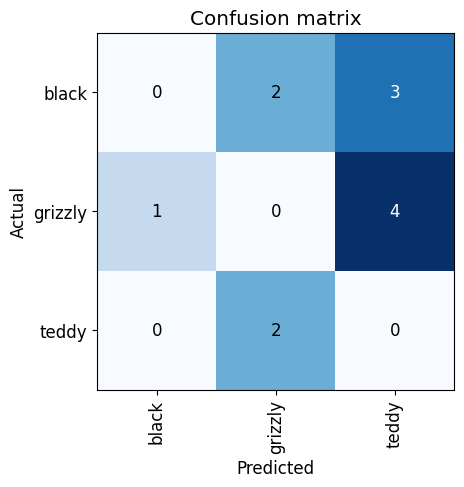

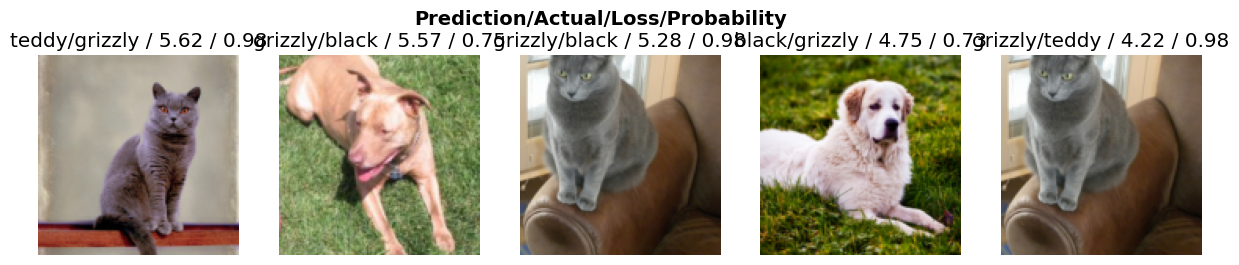

In [13]:
print("Fine-tuning ResNet18 with augmented data...")
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4) # Train for 4 epochs

print("Model trained. Analyzing performance...")
interp = ClassificationInterpretation.from_learner(learn)

print("Confusion Matrix:")
interp.plot_confusion_matrix()

print("Top Losses (potential mislabels):")
interp.plot_top_losses(5, nrows=1)

# ImageClassifierCleaner for interactive data cleaning
# Note: This will display an interactive widget in a Colab environment.
# User interaction is required to delete or relabel images.
print("Initializing ImageClassifierCleaner. Interact with the widget to clean data.")
cleaner = ImageClassifierCleaner(learn)
cleaner # This will display the widget

# To apply changes from the cleaner (run these in a separate cell after interacting with the widget):
# # Delete selected images
# for idx in cleaner.delete(): cleaner.fns[idx].unlink()

# # Move relabeled images
# for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

learn.export()
print("Model exported as export.pkl")

## 11. Interactive Classifier App
This section creates a graphical interface where you can upload an image and get an instant classification prediction.

## 6. Deployment Preparation
To deploy this as a standalone app, we need to create two main files: `app.py` (the Streamlit app) and `requirements.txt`.

In [ ]:
%%writefile app.py
import gradio as gr
from fastai.vision.all import *

# Load the model
learn = load_learner('export.pkl')
labels = learn.dls.vocab

def predict(img):
    img = PILImage.create(img)
    pred, pred_idx, probs = learn.predict(img)
    return {labels[i]: float(probs[i]) for i in range(len(labels))}

# Define the Gradio interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Bear Classifier",
    description="Upload an image to see if it's a Grizzly, Black, or Teddy bear!"
)

interface.launch()

In [ ]:
%%writefile requirements.txt
fastai
gradio
torch
ipython

### Next Steps for Deployment:
1. Download `app.py`, `requirements.txt`, and `export.pkl` from the Colab file browser (left sidebar).
2. Go to [Hugging Face Spaces](https://huggingface.co/spaces) and create a new Space.
3. Select **Streamlit** as the SDK.
4. Upload these three files to your new Space. Your app will build and go live automatically!